# Normal Lexrank on clean_text, rule_base, w2v, bert

In [ ]:
!pip install lexrank

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 6.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Columns in dataset: ['tweet', 'clean_text', 'cf_rule', 'cf_w2v', 'cf_bert']

Processing clean_text...

Summary for clean_text:

1. take that .... this me too is a well orchestrated feminist propaganda... it is clearly used to create a divide in families destroy the cultural fabric of family values
2. allowing a clear serial sexual predator to run one of your labels is a bad look, . you need to drop now.
3. hey , strangely you guys forgot to upload the clip  on allegations of sexual misconduct. one might get the idea didnt mention the story and isnt fun material anyway. or was there no time left for 16 women?
4. first hand account of a survivor from . publicly talks about her internship at tfi and the sexual harassment and abuse she faced. more power to you poulomi
5. the left has hyjacked the movement. the left does not believe in innocent until proven guilty. the left does not believe in america first instead they would rather put every country ahead of the united states.
6. home mini

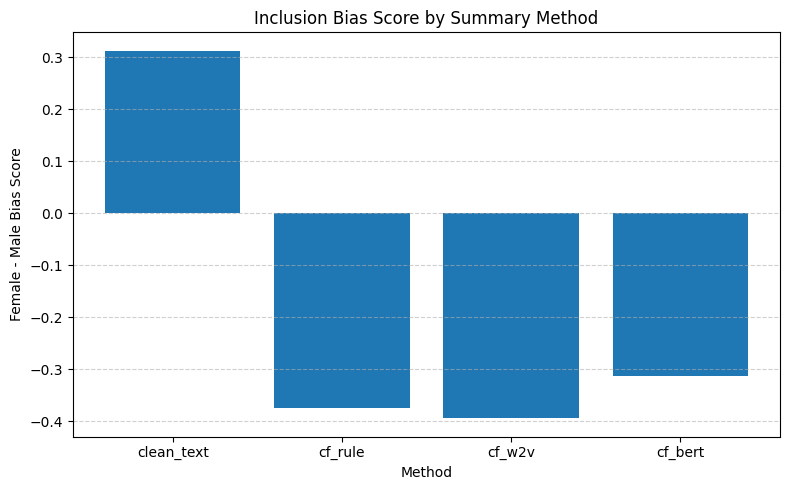

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from nltk.tokenize import TreebankWordTokenizer
from collections import Counter
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS
import nltk

nltk.download("punkt")

# -----------------------------
# Paths
# -----------------------------
file_path = "/content/sample_data/output.xlsx"
male_path = "/content/sample_data/male_list.csv"
female_path = "/content/sample_data/female_list.csv"

# -----------------------------
# Tokenizer + preprocessing
# -----------------------------
tokenizer = TreebankWordTokenizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    return tokenizer.tokenize(text)

# -----------------------------
# Load gender word lists
# -----------------------------
male_words = pd.read_csv(male_path, header=None)[0].astype(str).str.lower().tolist()
female_words = pd.read_csv(female_path, header=None)[0].astype(str).str.lower().tolist()

male_set = set(male_words)
female_set = set(female_words)

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_excel(file_path)
print("Columns in dataset:", df.columns.tolist())

# -----------------------------
# LexRank summary function
# -----------------------------
def lexrank_summary(texts, summary_size=25):
    tweets = [str(t).strip() for t in texts if pd.notna(t) and str(t).strip()]
    if len(tweets) == 0:
        return []

    lx = LexRank([tweets], stopwords=STOPWORDS["en"])
    summary = lx.get_summary(tweets, summary_size=summary_size, threshold=0.34)
    return summary

# -----------------------------
# Inclusion bias score function
# -----------------------------
def inclusion_bias_score(summary_sentences):
    combined_summary = " ".join(summary_sentences)
    tokens = preprocess(combined_summary)
    word_freq = Counter(tokens)

    matched_male = {word: word_freq[word] for word in male_set if word in word_freq}
    matched_female = {word: word_freq[word] for word in female_set if word in word_freq}

    # ✅ NEW: separate counts
    male_mentions = sum(matched_male.values())
    female_mentions = sum(matched_female.values())
    total_mentions = male_mentions + female_mentions

    if total_mentions == 0:
        male_score = 0.0
        female_score = 0.0
        bias_score = 0.0
    else:
        male_score = male_mentions / total_mentions
        female_score = female_mentions / total_mentions
        bias_score = female_score - male_score

    return {
        "combined_summary": combined_summary,
        "matched_male": matched_male,
        "matched_female": matched_female,
        "male_mentions": male_mentions,
        "female_mentions": female_mentions,
        "total_mentions": total_mentions,
        "male_score": male_score,
        "female_score": female_score,
        "bias_score": bias_score
    }

# -----------------------------
# Run for each column separately
# -----------------------------
columns = ["clean_text", "cf_rule", "cf_w2v", "cf_bert"]

results = []

for col in columns:
    print("\n" + "=" * 100)
    print(f"Processing {col}...\n")

    summary = lexrank_summary(df[col], summary_size=25)

    print(f"Summary for {col}:\n")
    for i, s in enumerate(summary, 1):
        print(f"{i}. {s}")

    score_info = inclusion_bias_score(summary)

    # ✅ Print detailed stats
    print(f"\n Male Mentions: {score_info['male_mentions']}")
    print(f" Female Mentions: {score_info['female_mentions']}")
    print(f" Total Gendered Mentions: {score_info['total_mentions']}")
    print(f" Weighted Male Score: {score_info['male_score']:.6f}")
    print(f" Weighted Female Score: {score_info['female_score']:.6f}")
    print(f" Bias Score (female - male): {score_info['bias_score']:.6f}")

    if score_info["bias_score"] > 0:
        direction = "biased toward females"
    elif score_info["bias_score"] < 0:
        direction = "biased toward males"
    else:
        direction = "neutral"

    print(f"⚪ Summary appears {direction}.")

    results.append({
        "column": col,
        "male_mentions": score_info["male_mentions"],
        "female_mentions": score_info["female_mentions"],
        "total_mentions": score_info["total_mentions"],
        "male_score": score_info["male_score"],
        "female_score": score_info["female_score"],
        "bias_score": score_info["bias_score"],
        "direction": direction,
        "summary_text": score_info["combined_summary"]
    })

# -----------------------------
# Results table
# -----------------------------
results_df = pd.DataFrame(results)

print("\n" + "=" * 100)
print("Final bias score results:\n")
print(results_df[[
    "column",
    "male_mentions",
    "female_mentions",
    "total_mentions",
    "male_score",
    "female_score",
    "bias_score",
    "direction"
]])

# Optional save
# results_df.to_excel("/content/sample_data/inclusion_bias_results.xlsx", index=False)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(results_df["column"], results_df["bias_score"])
plt.title("Inclusion Bias Score by Summary Method")
plt.ylabel("Female - Male Bias Score")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Gender+Lexrank on clean_text

In [ ]:
# Install spacy if not already installed
!pip install spacy pandas openpyxl

# Import libraries
import spacy
import pandas as pd

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import pandas as pd

# Load full dataset
file_path = "/content/sample_data/output.xlsx"
df = pd.read_excel(file_path)

# Keep only clean_text column (still as DataFrame)
df = df[["clean_text"]].dropna()

# Check
df.head()

,clean_text
0,take that .... this me too is a well orchestra...
1,only 40 charges and thousands of cries for hel...
2,former cricketer and cricket association of be...
3,my dream is that one day everyone will know wh...
4,"still,better than my neighbour or'stalker' as ..."


In [ ]:
# Define gender-specific keywords
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}

# Function to classify gender based on Spacy NER
def classify_gender_ner(text):
    doc = nlp(str(text))  # Process text with Spacy

    male_count = sum(1 for token in doc if token.text.lower() in male_terms)
    female_count = sum(1 for token in doc if token.text.lower() in female_terms)

    if male_count > female_count:
        return "Male"
    elif female_count > male_count:
        return "Female"
    elif male_count == female_count and male_count > 0:
        return "Both"
    else:
        return "Neutral/Unclear"


In [ ]:
df["Gender_Category"] = df["clean_text"].astype(str).apply(classify_gender_ner)
df.head()

,clean_text,Gender_Category
0,take that .... this me too is a well orchestra...,Female
1,only 40 charges and thousands of cries for hel...,Neutral/Unclear
2,former cricketer and cricket association of be...,Neutral/Unclear
3,my dream is that one day everyone will know wh...,Neutral/Unclear
4,"still,better than my neighbour or'stalker' as ...",Male


In [ ]:
print(df.columns)

Index(['clean_text', 'Gender_Category'], dtype='object')


In [ ]:
# Create separate DataFrames
male_tweets = df[df["Gender_Category"] == "Male"]
female_tweets = df[df["Gender_Category"] == "Female"]
both_tweets = df[df["Gender_Category"] == "Neutral/Unclear"]

In [ ]:
print("Male:", len(male_tweets))
print("Female:", len(female_tweets))
print("Both:", len(both_tweets))

Male: 92
Female: 164
Both: 187


In [ ]:
male_tweets = male_tweets[["clean_text"]]
female_tweets = female_tweets[["clean_text"]]
both_tweets = both_tweets[["clean_text"]]

In [ ]:
male_tweets.to_excel("/content/sample_data/male_tweets.xlsx", index=False)
female_tweets.to_excel("/content/sample_data/female_tweets.xlsx", index=False)
both_tweets.to_excel("/content/sample_data/both_tweets.xlsx", index=False)

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def compute_similarity_bert(texts):
    # Encode sentences → embeddings
    embeddings = model.encode(texts, convert_to_numpy=True)

    # Cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings)

    return similarity_matrix

In [ ]:
male_texts = male_tweets["clean_text"].astype(str).tolist()
female_texts = female_tweets["clean_text"].astype(str).tolist()
both_texts = both_tweets["clean_text"].astype(str).tolist()

In [ ]:
male_sim = compute_similarity_bert(male_texts)
female_sim = compute_similarity_bert(female_texts)
both_sim = compute_similarity_bert(both_texts)

In [ ]:
def create_pairs(texts, sim_matrix):
    pairs = []

    n = len(texts)

    for i in range(n):
        for j in range(i + 1, n):   # avoid duplicates + self-pairs
            pairs.append({
                "Tweet 1": texts[i],
                "Tweet 2": texts[j],
                "Similarity Score": sim_matrix[i][j]
            })

    return pd.DataFrame(pairs)

In [ ]:
male_similarity_df = create_pairs(male_texts, male_sim)
female_similarity_df = create_pairs(female_texts, female_sim)
both_similarity_df = create_pairs(both_texts, both_sim)

In [ ]:
male_similarity_df.head()

,Tweet 1,Tweet 2,Similarity Score
0,"still,better than my neighbour or'stalker' as ...",if you excuse your boys behavior you create an...,0.248961
1,"still,better than my neighbour or'stalker' as ...",thanks for being the rare voice in the industr...,0.224428
2,"still,better than my neighbour or'stalker' as ...",i have been asking media houses to debate this...,0.114307
3,"still,better than my neighbour or'stalker' as ...","it's also not ok to abuse, threaten attempt t...",0.266797
4,"still,better than my neighbour or'stalker' as ...",this looks great but sean penns opinions on th...,0.091354


In [ ]:
male_similarity_df.to_excel("/content/sample_data/male_similarity.xlsx", index=False)
female_similarity_df.to_excel("/content/sample_data/female_similarity.xlsx", index=False)
both_similarity_df.to_excel("/content/sample_data/both_similarity.xlsx", index=False)

In [ ]:
# Ensure enough data
assert len(male_similarity_df) >= 50

male_50_pairs = male_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

male_50_pairs.to_excel("/content/sample_data/male_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(female_similarity_df) >= 50

female_50_pairs = female_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

female_50_pairs.to_excel("/content/sample_data/female_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(both_similarity_df) >= 50

both_50_pairs = both_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

both_50_pairs.to_excel("/content/sample_data/both_50_random_pairs.xlsx", index=False)

In [ ]:
male_tweets_list = list(
    set(male_50_pairs["Tweet 1"]).union(set(male_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([male_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
male_summary = lx.get_summary(
    male_tweets_list,
    summary_size=25,
    threshold=0.15   # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": male_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/male_summary.xlsx", index=False)
print("Summary saved as male_summary.xlsx")

Summary saved as male_summary.xlsx


In [ ]:
print("Male Summary:\n")
for i, s in enumerate(male_summary, 1):
    print(f"{i}. {s}")

Male Summary:

1. when settlement amount is the motive by falsely charging a man' it's called pls tk action on ppl filing  bring .
2. the only time their ears seem to prick up or blood starts to boil, is when the perpetrators of such crimes are muslim men, they dont want to accept how commonplace this all is.
3. if you excuse your boys behavior you create an asshole. be responsible because assholes will always ended up in jail or lonely.
4. hey jack, not cool man, not cool. you don't get to spew false information and taint the movement. take a hike!
5. i completely support . this is involved in a bigger communist plot to undermine actors who have right wing inclinations. this is nothing but sham and disrespecting a legend. shame!
6. of all the rags to put it out, it has to be radar! online. however it's a legit court doc! truth is out! yeah they're trying to bury it and spread more bs about potc and john mcafree. wake up, y'all need to stop dismissing male abuse survivors.
7. activist 

In [ ]:
female_tweets_list = list(
    set(female_50_pairs["Tweet 1"]).union(set(female_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([female_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
female_summary = lx.get_summary(
    female_tweets_list,
    summary_size=25,
    threshold=0.34  # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": female_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/female_summary.xlsx", index=False)
print("Summary saved as female_summary.xlsx")

Summary saved as female_summary.xlsx


In [ ]:
print("Female Summary:\n")
for i, s in enumerate(female_summary, 1):
    print(f"{i}. {s}")

Female Summary:

1. the first story on talk, dammit was mine. the first person i opened up to about having been molested as a child was faizan. please dont believe this attention seeking bully of a woman, faizan has been there for me and countless others even before there was a movement.
2. i did. to equate tht with  not only shows that you are a bitter old woman who has no respect for hinduism, our culture, our tradition, the choice of women to do what they want, or the  mvmnt, but also that writing soft porn has incapacitated ur mental faculties
3. i guess canadians' financial information are like female journalists, when you're prime minister of canada you don't need their consent.
4. i want to talk abt something i have only briefly touched upon in the past. it is an important discourse that connects to many others, including live in a world that epitomizes savarna women. the expectation to meet the savarna ideal is ever present.
5. if people believe dat is lyin bout bein raped by d

In [ ]:
both_tweets_list = list(
    set(both_50_pairs["Tweet 1"]).union(set(both_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([both_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
both_summary = lx.get_summary(
    both_tweets_list,
    summary_size=25,
    threshold=0.25   # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": both_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/both_summary.xlsx", index=False)
print("Summary saved as both_summary.xlsx")

Summary saved as both_summary.xlsx


In [ ]:
print("Both Summary:\n")
for i, s in enumerate(both_summary, 1):
    print(f"{i}. {s}")

Both Summary:

1. what is the doing to support the implementation of demands raised by ?
2. yesterday \"sweetu\" is 2day's using .
3. a year ago today i thought my world was falling apart. i woke up to find out that the hashtag had gone viral and i didn't see any of the work i laid out over the previous decade attached to it. i thought for sure i would be erased from a thing i worked so hard to build. +
4. "one of the best commentaries on convicting a person without sufficient proof is a bigger crime than not convicting a criminal. because the number of innocent people affected potentially becomes much bigger \"social bomb\" than the number of criminals.
5. thank you for a fantastic session which was and on the of under
6. i i was hoping you had a heart apparently not if your supporter then you thing hatred and bigotry and division of our country is a great thing we
7. cm aware, apprised, still no action against predator minister. why is the congress party silent?? we demand strictest 

In [ ]:
!pip install bertopic sentence-transformers networkx openpyxl

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
male_df = pd.read_excel("/content/sample_data/male_summary.xlsx")
female_df = pd.read_excel("/content/sample_data/female_summary.xlsx")
both_df = pd.read_excel("/content/sample_data/both_summary.xlsx")

male_summary = male_df["summary"].dropna().astype(str).tolist()
female_summary = female_df["summary"].dropna().astype(str).tolist()
both_summary = both_df["summary"].dropna().astype(str).tolist()

# -----------------------------
# Combine all summaries
# -----------------------------
combined_sentences = male_summary + female_summary + both_summary

print(f"Total combined sentences: {len(combined_sentences)}")

Total combined sentences: 75


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(combined_sentences, convert_to_tensor=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

In [ ]:
threshold = 0.32
G = nx.Graph()

# Add nodes
for idx, sentence in enumerate(combined_sentences):
    G.add_node(idx, sentence=sentence)

# Add edges based on similarity threshold
for i in range(len(combined_sentences)):
    for j in range(i+1, len(combined_sentences)):
        sim = similarity_matrix[i][j]
        if sim >= threshold:
            G.add_edge(i, j, weight=sim)

In [ ]:
scores = nx.pagerank(G, weight='weight')
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(combined_sentences)), reverse=True)
summary_lexrank = [sent for score, sent in ranked_sentences[:25]]

# Print summary
print("\n".join(summary_lexrank))

when will women realise that they r digging a well for themselves by false allegations
it's an excellent example of hypocrisy by govt, when innocent men's where roped in fake which lead them to there wasn't anyone to come in support, but when opportunistic like stepped in then committee was formed
this psycho female has sympathy for all the bollywood turds on . but she can't tolerate one woman sannyasi exposing the filth of congress. what shows is the fake hindu terror you spread what u forget is, u may try to mess with the truth, but u cant hide it
fox and conservative media will roll with push this new theory and claim media is covering it up. they will try to shrink the gender gap just before the election. it's weaponizing the way they assumed dems did against kavanaugh. probably what inspired this.
this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.
i

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')   # <-- IMPORTANT (your error specifically asks this)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def count_gender_terms(summary, male_terms, female_terms):
    male_count = 0
    female_count = 0
    stop_words = set(stopwords.words('english'))  # This line requires the stopwords import

    for sentence in summary:
        words = word_tokenize(sentence.lower())  # Tokenize each sentence into words
        filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

        for word in filtered_words:
            if word in male_terms:
                male_count += 1
            elif word in female_terms:
                female_count += 1

    return male_count, female_count

In [ ]:
# Gender term lists
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}

In [ ]:
combined_summary = [
    "when will women realise that they r digging a well for themselves by false allegations",
    "it's an excellent example of hypocrisy by govt, when innocent men's where roped in fake which lead them to there wasn't anyone to come in support, but when opportunistic like stepped in then committee was formed",
    "this psycho female has sympathy for all the bollywood turds on . but she can't tolerate one woman sannyasi exposing the filth of congress. what shows is the fake hindu terror you spread what u forget is, u may try to mess with the truth, but u cant hide it",
    "fox and conservative media will roll with push this new theory and claim media is covering it up. they will try to shrink the gender gap just before the election. it's weaponizing the way they assumed dems did against kavanaugh. probably what inspired this.",
    "this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.",
    "i once predicted abt rise of feminism, and we can now see the same in form of .. this is nothing but but many male friends has to sacrifice their life, career for women publicity..",
    "these companies are leading the change needed for closing the gender gap. in the age of the movement, the 100 best workplaces for women have demonstrated that the office can be a refuge for personal dignity, respect, and hope",
    "cheapster, such girls mowed down the image of todays women, all women should oppose her",
    "see bjp never respects women, while criticizing inc they give example of shows how serious are they? dont believe women will ever get justice till bjp in power. __",
    "'i was shamed and humiliated': adhyayan suman on sharing his story 2 years ago against kangana ranaut | bollywood news if man suffer media house never support , its not 4 both , dont get fool . to stop .",
    "lovely work. and so true that the movement includes dads, sons and brothers w the integrity, class, strength and grace to push back against primitive male traditions and behavior. parents now must raise boys to be civilized and girls who will not suffer abuse in silence.",
    "my latest on listening to black women organizing around sexual violence by police officers feat.",
    "important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting her editor-predator . she needs our support.",
    "will not survive unless we recognize toxic femininity women are not monolithic. pretending they are holds everyone back.",
    "it is becoming more commonplace for schools to offer support groups for boys. here they feel safe to discuss their emotions and learn to navigate their relationship with girls in the movement boy talk: breaking masculine stereotypes",
    "let it be the beginning of a movement.. let whole india when this can happen to a person like paaji .. then a common man what will be his situation.. bcoz of stigma he may attempt suicide ..so these spoiled brats n fraudulent champs must be exposed..",
    "any feminist lawyers out there want to join forces and learn cutting edge defamation law so we can protect people who speak out in the movement? im in vancouver and want to join a collective to level the playing field!",
    "i thoroughly enjoy being in a room full of men, who talk about the movement. i really like their perspective on how they need their own movement. how enlightening.",
    "now this is the other side of the movement which makes many apprehensive about an all-out support to the surely needed  important social movement ... there are good  bad on both sides , what's important is to ensure that only the bad are taken to task  difficult task",
    "i have been asking media houses to debate this but these spineless guys don't ever discuss such incidents. biased media could only talk at prime time to demean the men of this country. poor guard with no mistake is behind bars . jago jago",
    "i completely support . this is involved in a bigger communist plot to undermine actors who have right wing inclinations. this is nothing but sham and disrespecting a legend. shame!",
    "thank you together we can tackle sexual harassment. we need a national conversation and a national survey to expose how widespread it is in welsh society so we can move to eliminate it. a support network is an excellent idea.",
    "of course. the natural progression of labeling women who come forward with credible claims of assault against your allies as lying sluts is to weaponize against your enemies. they think its a huge gotcha. please prove them wrong.",
    "even though there was no penetration which is statutory rape this is still pedophilia and a felony. this person molested and filmed a child groomed to give oral sex. what this a child of colour? is this what makes judgements for pedophilia so lenient?",
    "mumbai lokhanwala hit guard unnecessarily then striped off herself to avoid arrest and then played"
]
male_count, female_count = count_gender_terms(combined_summary, male_terms, female_terms)

# Avoid division by zero
total = male_count + female_count
if total > 0:
    male_ratio = male_count / total
    female_ratio = female_count / total
    bias_score = female_ratio - male_ratio
else:
    male_ratio = female_ratio = bias_score = 0

# Display results
print(f"Male Mentions: {male_count}")
print(f"Female Mentions: {female_count}")
print(f"Bias Score (female - male): {bias_score:.2f}")

if bias_score > 0:
    print("🟣 Summary is biased toward females.")
elif bias_score < 0:
    print("🔵 Summary is biased toward males.")
else:
    print("⚪ Summary appears neutral.")

Male Mentions: 14
Female Mentions: 18
Bias Score (female - male): 0.12
🟣 Summary is biased toward females.


 Male Mentions: 17
 Female Mentions: 23
 Bias Score (female - male): 0.1500
 Summary is biased toward females.


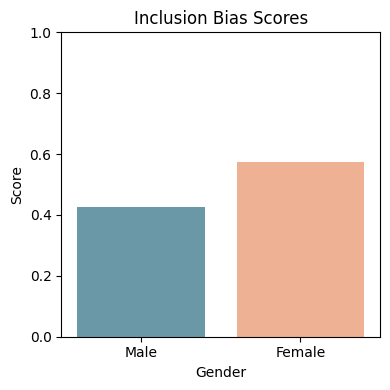

(0.425, 0.575, 0.14999999999999997)

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}


# -----------------------------
# CORRECT FUNCTION
# -----------------------------
def calculate_weighted_bias(summary, male_terms, female_terms):

    # Join if list
    if isinstance(summary, list):
        summary = ' '.join(summary)

    # Lowercase
    summary = summary.lower()

    # 🔥 KEY FIX: clean tokenization
    words = re.findall(r'\b[a-z]+\b', summary)

    # Frequency count
    word_freq = Counter(words)

    # Count using SAME logic as first method
    male_count = sum(word_freq[word] for word in word_freq if word in male_terms)
    female_count = sum(word_freq[word] for word in word_freq if word in female_terms)

    total = male_count + female_count

    if total > 0:
        male_ratio = male_count / total
        female_ratio = female_count / total
        bias_score = female_ratio - male_ratio
    else:
        male_ratio = female_ratio = bias_score = 0

    # -----------------------------
    # Print results
    # -----------------------------
    print(f" Male Mentions: {male_count}")
    print(f" Female Mentions: {female_count}")
    print(f" Bias Score (female - male): {bias_score:.4f}")

    if bias_score > 0:
        print(" Summary is biased toward females.")
    elif bias_score < 0:
        print(" Summary is biased toward males.")
    else:
        print(" Summary appears neutral.")

    # -----------------------------
    # Optional visualization
    # -----------------------------
    df = pd.DataFrame({
        'Gender': ['Male', 'Female'],
        'Score': [male_ratio, female_ratio]
    })

    plt.figure(figsize=(4,4))
    sns.barplot(x='Gender', y='Score', data=df,
                palette=["#609db0", "#fdac84"])
    plt.title("Inclusion Bias Scores")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

    return male_ratio, female_ratio, bias_score


# -----------------------------
# SUMMARY (paste yours)
# -----------------------------
combined_summary = [
    "when will women realise that they r digging a well for themselves by false allegations",
    "it's an excellent example of hypocrisy by govt, when innocent men's where roped in fake which lead them to there wasn't anyone to come in support, but when opportunistic like stepped in then committee was formed",
    "this psycho female has sympathy for all the bollywood turds on . but she can't tolerate one woman sannyasi exposing the filth of congress. what shows is the fake hindu terror you spread what u forget is, u may try to mess with the truth, but u cant hide it",
    "fox and conservative media will roll with push this new theory and claim media is covering it up. they will try to shrink the gender gap just before the election. it's weaponizing the way they assumed dems did against kavanaugh. probably what inspired this.",
    "this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.",
    "i once predicted abt rise of feminism, and we can now see the same in form of .. this is nothing but but many male friends has to sacrifice their life, career for women publicity..",
    "these companies are leading the change needed for closing the gender gap. in the age of the movement, the 100 best workplaces for women have demonstrated that the office can be a refuge for personal dignity, respect, and hope",
    "cheapster, such girls mowed down the image of todays women, all women should oppose her",
    "see bjp never respects women, while criticizing inc they give example of shows how serious are they? dont believe women will ever get justice till bjp in power. __",
    "'i was shamed and humiliated': adhyayan suman on sharing his story 2 years ago against kangana ranaut | bollywood news if man suffer media house never support , its not 4 both , dont get fool . to stop .",
    "lovely work. and so true that the movement includes dads, sons and brothers w the integrity, class, strength and grace to push back against primitive male traditions and behavior. parents now must raise boys to be civilized and girls who will not suffer abuse in silence.",
    "my latest on listening to black women organizing around sexual violence by police officers feat.",
    "important cases remain without attention. ..those who may not be a celebrated journo, or not from the english media. here's the struggle of a young journalist from nbt fighting her editor-predator . she needs our support.",
    "will not survive unless we recognize toxic femininity women are not monolithic. pretending they are holds everyone back.",
    "it is becoming more commonplace for schools to offer support groups for boys. here they feel safe to discuss their emotions and learn to navigate their relationship with girls in the movement boy talk: breaking masculine stereotypes",
    "let it be the beginning of a movement.. let whole india when this can happen to a person like paaji .. then a common man what will be his situation.. bcoz of stigma he may attempt suicide ..so these spoiled brats n fraudulent champs must be exposed..",
    "any feminist lawyers out there want to join forces and learn cutting edge defamation law so we can protect people who speak out in the movement? im in vancouver and want to join a collective to level the playing field!",
    "i thoroughly enjoy being in a room full of men, who talk about the movement. i really like their perspective on how they need their own movement. how enlightening.",
    "now this is the other side of the movement which makes many apprehensive about an all-out support to the surely needed  important social movement ... there are good  bad on both sides , what's important is to ensure that only the bad are taken to task  difficult task",
    "i have been asking media houses to debate this but these spineless guys don't ever discuss such incidents. biased media could only talk at prime time to demean the men of this country. poor guard with no mistake is behind bars . jago jago",
    "i completely support . this is involved in a bigger communist plot to undermine actors who have right wing inclinations. this is nothing but sham and disrespecting a legend. shame!",
    "thank you together we can tackle sexual harassment. we need a national conversation and a national survey to expose how widespread it is in welsh society so we can move to eliminate it. a support network is an excellent idea.",
    "of course. the natural progression of labeling women who come forward with credible claims of assault against your allies as lying sluts is to weaponize against your enemies. they think its a huge gotcha. please prove them wrong.",
    "even though there was no penetration which is statutory rape this is still pedophilia and a felony. this person molested and filmed a child groomed to give oral sex. what this a child of colour? is this what makes judgements for pedophilia so lenient?",
    "mumbai lokhanwala hit guard unnecessarily then striped off herself to avoid arrest and then played"
]
# -----------------------------
# RUN
# -----------------------------
calculate_weighted_bias(combined_summary, male_terms, female_terms)